# Daylight surrogate training and run history

This experiment distils an illustrative multi-bounce room oracle into occupant-plane **Ev** and **Et** estimates. The controller remains unchanged. Results are modelled lux, not measured occupant comfort.

## Context and assumptions

Independent local data, Putrajaya (2.922° N), seeded synthetic weather. Twelve west/south dates cover solstices, equinoxes and the near-equatorial overhead passages; east/north use three never-trained dates. The room is an empty 6.4 × 6.4 × 3.6 m box with a full-wall aperture; furniture, partitions and glass spectral effects are omitted. Chair positions/facing mirror the illustrative floor drawing. Walls/floor/ceiling reflect 0.5/0.2/0.8. Four radiosity passes, 4 × 4 patches per surface, efficacy 110 lm/W.

Method precedent: [Tabatabaei Manesh et al., 2025](https://doi.org/10.1016/j.autcon.2025.106474); efficacy approximation: [Littlefair, 1988](https://doi.org/10.1177/096032718802000405). No external weights or dataset are reused.

**Selection criterion: MAE in lux.** Structural holdout is a validation set used for selection; orientation transfer remains untouched. Transfer acceptance was declared before fitting: MAE ≤ 1.5 × structural MAE + 50 lux, per target. Failures restrict serving to west/south. Linear matching Extra Trees stops Phase B.

Run from a clean kernel with `make daylight-train`. All fitting, splits, metrics, diagnostics and ledger writes live in `app.domain.daylight.training`.

## 1. Parameters

In [1]:
import os
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from app.config import DEFAULTS
from app.domain.daylight import training

BACKEND = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(BACKEND)
DATASET = Path("data/daylight/dataset")
LEDGER = Path("../docs/appendix/daylight-runs.jsonl")
MODEL_DIR = Path(DEFAULTS.daylight_model_dir)
REPORT = Path("../docs/appendix/daylight-training-results.md")
SEED = DEFAULTS.seed
TARGETS = ("ev", "et")
GRID = {target: training.model_grid(target) for target in TARGETS}
SEARCH_ITERATIONS = 2
COLORS = {"ev": "#315c83", "et": "#ba783a"}
plt.rcParams.update(
    {
        "figure.figsize": (10, 4),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.constrained_layout.use": True,
    }
)
display(GRID)

{'ev': {'n_estimators': [200],
  'min_samples_split': [2, 5],
  'min_samples_leaf': [1, 3],
  'max_depth': [20, 30]},
 'et': {'n_estimators': [100],
  'min_samples_split': [2, 5],
  'min_samples_leaf': [1, 3],
  'max_depth': [20, 30]}}

## 2. Data and fingerprint

In [2]:
frame, dataset_sha256 = training.load_dataset(DATASET)
display(
    Markdown(
        f"**{len(frame):,} rows**, {frame.day_id.min()}–{frame.day_id.max()}, "
        f"seed {SEED}. Dataset SHA-256: `{dataset_sha256}`"
    )
)
display(
    frame.groupby(["split_role", "orientation"]).agg(
        rows=("tick", "size"), days=("day_id", "nunique"), zones=("zone", "nunique")
    )
)

**192,829 rows**, 2026-01-21–2026-12-21, seed 42. Dataset SHA-256: `b69fb674df4594977c5e8c9965d8fee2869537203617da32f5511e2df4a8a170`

rows  days  zones
split_role orientation                    
train      south        72670    12      8
           west         81120    12      8
transfer   east         20592     3      8
           north        18447     3      8

## 3. Target distributions

All magnitudes are retained. A logarithmic count axis makes rare bright exposures visible; lux remains linear. Ev includes seats only.

,EV lux
count,148330.000000
mean,1010.212719
std,1352.175048
min,5.256512
25%,225.751071
50%,483.630726
75%,1222.736552
max,20597.246049


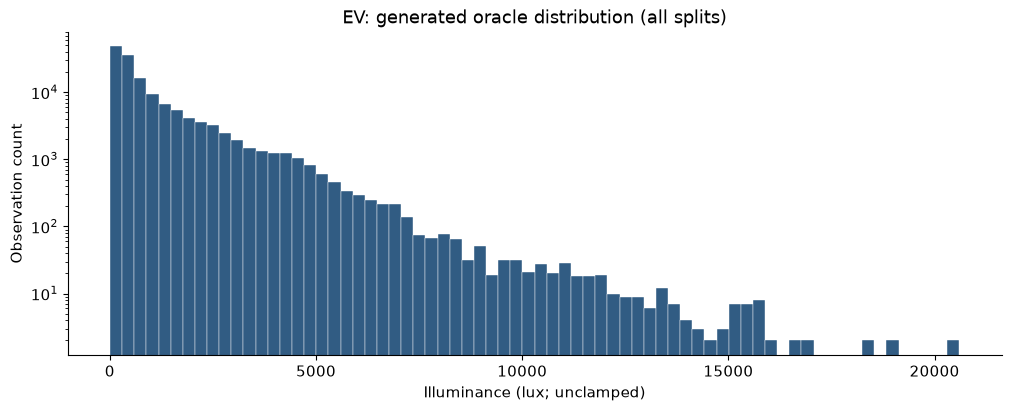

,ET lux
count,192829.000000
mean,1162.176433
std,1296.584733
min,8.669190
25%,352.804944
50%,754.626103
75%,1581.264090
max,17911.618065


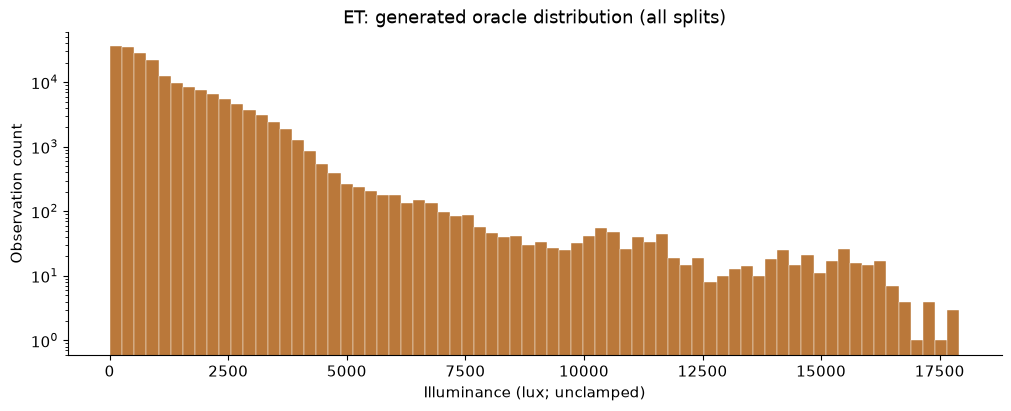

In [3]:
for target in TARGETS:
    values = frame.loc[frame.probe_kind == "seat", "ev_lux"] if target == "ev" else frame.et_lux
    display(values.describe(percentiles=[0.25, 0.5, 0.75]).to_frame(f"{target.upper()} lux"))
    fig, ax = plt.subplots()
    ax.hist(values, bins=70, color=COLORS[target], edgecolor="white", linewidth=0.3)
    ax.set(
        title=f"{target.upper()}: generated oracle distribution (all splits)",
        xlabel="Illuminance (lux; unclamped)",
        ylabel="Observation count",
        yscale="log",
    )
    plt.show()

## 4. Five-fold search and fitting

The shuffled sample shares days/zones with fitting. Structural holdout has **both unseen days and unseen zones**; cross-strata are excluded. The full search folds hold out whole training days. Two deterministic random candidates per model use the paper’s parameters as priors. The linear baseline uses the same features and splits.

In [4]:
splits, models, all_metrics = {}, {}, []
for target in TARGETS:
    splits[target] = training.build_splits(frame, target=target, seed=SEED)
    models[target], metrics = training.tune_models(
        splits[target], grid=GRID[target], n_iter=SEARCH_ITERATIONS
    )
    all_metrics.extend(metrics)
selected = {
    target: training.winner([m for m in all_metrics if m.target == target]) for target in TARGETS
}

ev extra trees: holdout MAE 106.98 lux


ev random forest: holdout MAE 187.94 lux


ev linear: holdout MAE 563.62 lux


et extra trees: holdout MAE 105.89 lux


et random forest: holdout MAE 121.35 lux


et linear: holdout MAE 442.78 lux


## 5. Metrics: shuffled → structural → orientation transfer

MAE is lux; MSE is lux². The incumbent predicts Et only: it has no eye-plane metric. Selection uses structural MAE; transfer has no effect on which model wins.

In [5]:
metrics_table = pd.DataFrame([vars(metric) for metric in all_metrics])
for columns in (
    ["target", "model", "mae_shuffled", "mae_holdout", "mae_transfer"],
    ["target", "model", "r2_shuffled", "r2_holdout", "r2_transfer"],
    ["target", "model", "mse_shuffled", "mse_holdout", "mse_transfer"],
):
    display(metrics_table[columns].round(3))
for target, metric in selected.items():
    display(
        Markdown(
            f"**{target.upper()} selected: {metric.model}.** Structural minus shuffled "
            f"MAE: {metric.mae_holdout - metric.mae_shuffled:+.2f} lux."
        )
    )

,target,model,mae_shuffled,mae_holdout,mae_transfer
0,ev,extra trees,18.127,106.978,141.354
1,ev,random forest,25.593,187.937,172.152
2,ev,linear,560.368,563.617,617.902
3,et,extra trees,28.571,105.893,94.601
4,et,random forest,33.631,121.352,103.551
5,et,linear,517.230,442.782,411.585
6,et,incumbent scalar,1175.489,1131.562,815.499


,target,model,r2_shuffled,r2_holdout,r2_transfer
0,ev,extra trees,0.995,0.971,0.971
1,ev,random forest,0.992,0.926,0.942
2,ev,linear,0.539,0.616,0.623
3,et,extra trees,0.978,0.962,0.954
4,et,random forest,0.974,0.954,0.927
5,et,linear,0.605,0.652,0.525
6,et,incumbent scalar,-0.651,-0.789,-0.959


,target,model,mse_shuffled,mse_holdout,mse_transfer
0,ev,extra trees,8186.036,57069.156,53532.444
1,ev,random forest,14292.345,142801.614,106566.157
2,ev,linear,793592.915,745125.368,699322.763
3,et,extra trees,43858.633,58401.236,30518.281
4,et,random forest,51887.361,70883.327,47725.657
5,et,linear,788938.841,536340.880,311501.125
6,et,incumbent scalar,3296705.748,2758541.555,1285741.289


**EV selected: extra trees.** Structural minus shuffled MAE: +88.85 lux.

**ET selected: extra trees.** Structural minus shuffled MAE: +77.32 lux.

## 6. Feature importance

Tree impurity importance is a diagnostic, not a causal attribution. Spatial versus weather importance is inspected rather than assumed.

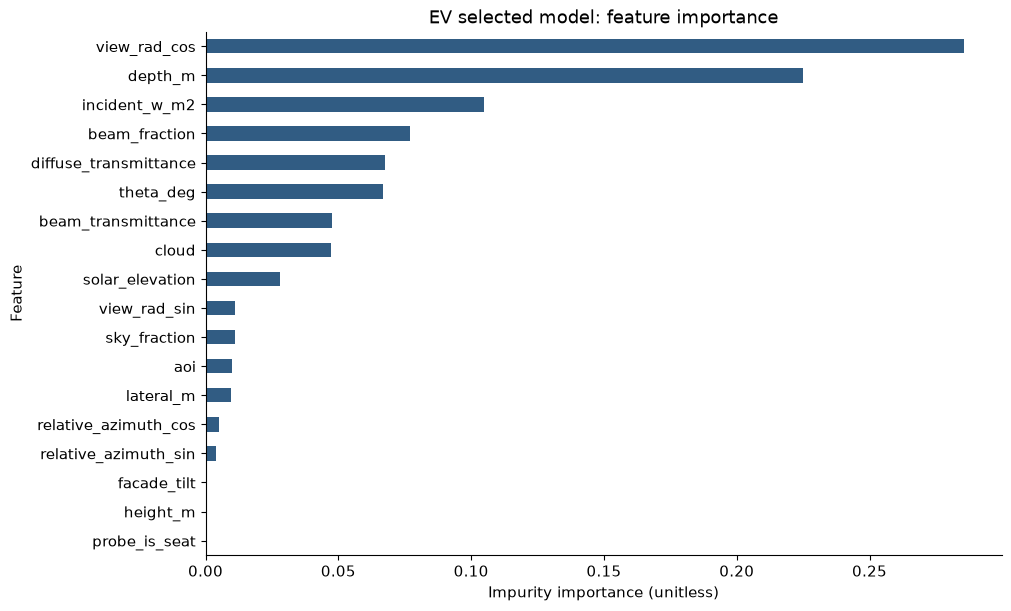

Largest importance: **view_rad_cos** (0.285).

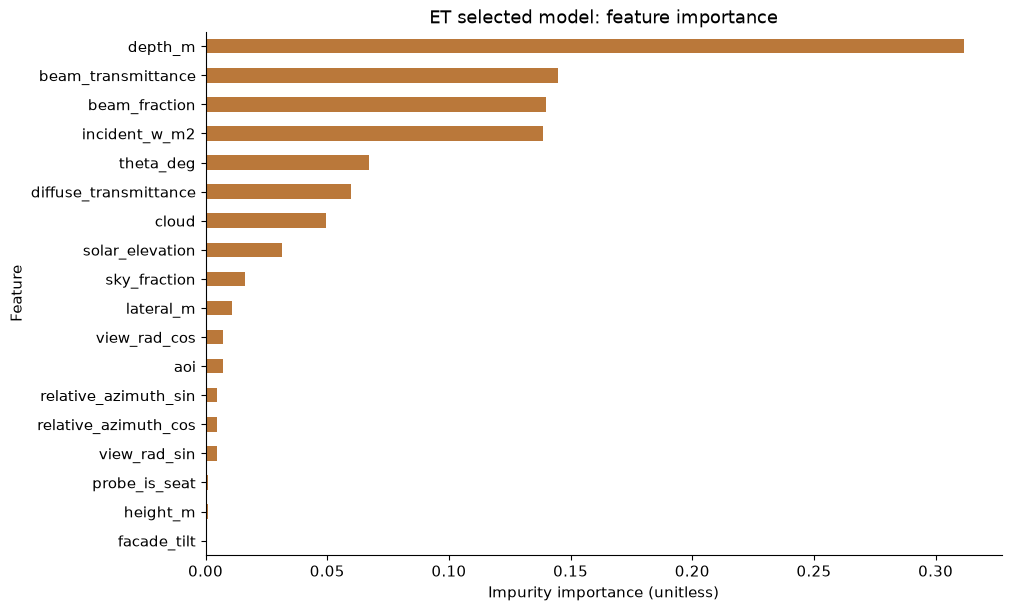

Largest importance: **depth_m** (0.312).

In [6]:
for target in TARGETS:
    model = models[target][selected[target].model]
    importance = getattr(model, "feature_importances_", None)
    if importance is not None:
        values = pd.Series(importance, index=training.FEATURE_NAMES).sort_values()
        fig, ax = plt.subplots(figsize=(10, 6))
        values.plot.barh(ax=ax, color=COLORS[target])
        ax.set(
            title=f"{target.upper()} selected model: feature importance",
            xlabel="Impurity importance (unitless)",
            ylabel="Feature",
        )
        plt.show()
        display(Markdown(f"Largest importance: **{values.idxmax()}** ({values.max():.3f})."))

## 7. Predictions and residuals

Every structural-holdout observation is shown. Actual lux, predicted lux and residuals are unclamped.

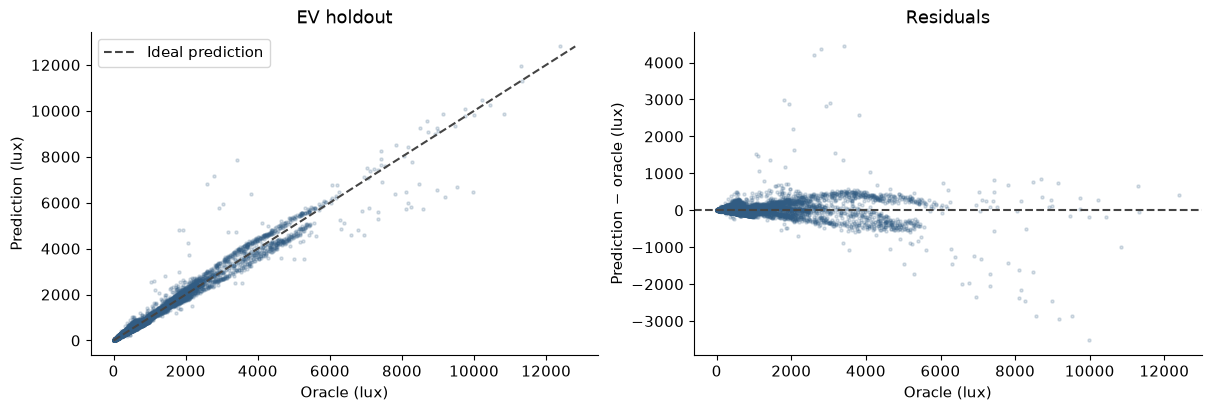

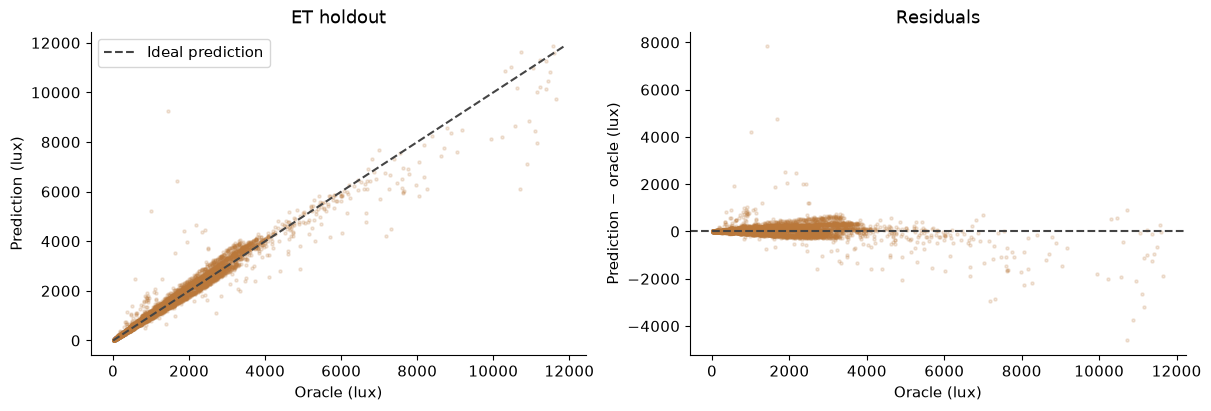

In [7]:
predictions = {}
for target in TARGETS:
    rows = training.prediction_rows(splits[target], models[target][selected[target].model])
    predictions[target] = rows
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(rows.actual_lux, rows.predicted_lux, s=5, alpha=0.18, color=COLORS[target])
    limit = max(rows.actual_lux.max(), rows.predicted_lux.max())
    axes[0].plot([0, limit], [0, limit], "--", color="#444444", label="Ideal prediction")
    axes[0].set(xlabel="Oracle (lux)", ylabel="Prediction (lux)", title=f"{target.upper()} holdout")
    axes[0].legend()
    axes[1].scatter(rows.actual_lux, rows.residual_lux, s=5, alpha=0.18, color=COLORS[target])
    axes[1].axhline(0, linestyle="--", color="#444444")
    axes[1].set(xlabel="Oracle (lux)", ylabel="Prediction − oracle (lux)", title="Residuals")
    plt.show()

## 8. Best and worst probe sets

Sets share date, zone, tick and louvre angle. Ranking uses their mean absolute error. A poor worst case is retained even when the overall average looks good.

,day_id,zone,tick,theta_deg,probe_index,depth_m,actual_lux,predicted_lux,residual_lux,absolute_error_lux,set_mae_lux
3,2026-08-21,S13,48,60.0,0,5.35,8.02,9.00,0.97,0.97,2.39
4,2026-08-21,S13,48,60.0,1,4.67,7.18,7.68,0.50,0.50,2.39
5,2026-08-21,S13,48,60.0,11,1.89,72.21,77.82,5.61,5.61,2.39
6,2026-08-21,S13,48,60.0,13,0.20,16.20,13.71,-2.49,2.49,2.39
0,2026-01-21,W14,96,50.0,3,1.63,2079.22,3706.61,1627.38,1627.38,918.21
1,2026-01-21,W14,96,50.0,7,4.77,423.21,569.18,145.97,145.97,918.21
2,2026-01-21,W14,96,50.0,9,1.46,10830.01,9848.73,-981.28,981.28,918.21


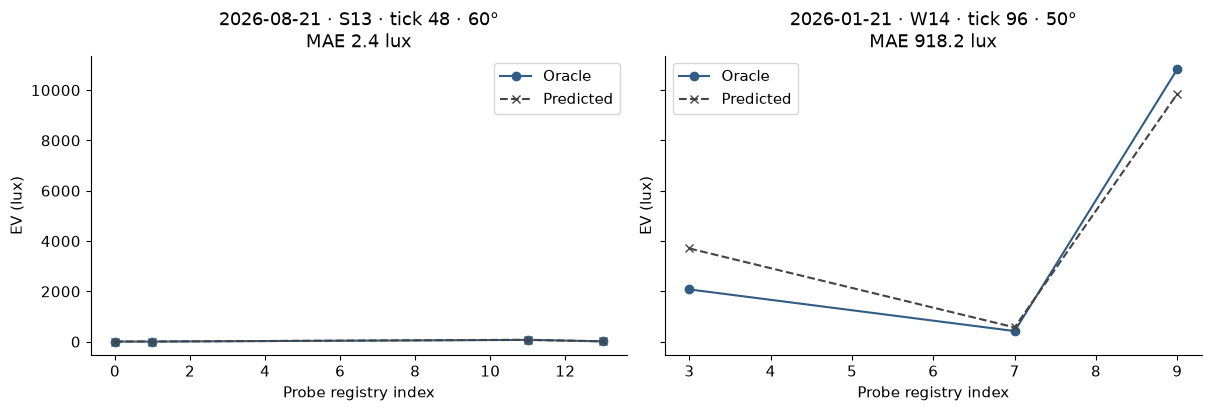

,day_id,zone,tick,theta_deg,probe_index,depth_m,actual_lux,predicted_lux,residual_lux,absolute_error_lux,set_mae_lux
6,2026-09-15,W14,48,60.0,3,1.63,53.94,53.89,-0.05,0.05,0.88
7,2026-09-15,W14,48,60.0,7,4.77,19.90,19.68,-0.22,0.22,0.88
8,2026-09-15,W14,48,60.0,8,0.99,70.37,72.16,1.78,1.78,0.88
9,2026-09-15,W14,48,60.0,9,1.46,59.89,58.41,-1.47,1.47,0.88
0,2026-08-21,W13,96,50.0,0,0.96,11495.09,10838.94,-656.15,656.15,2068.78
1,2026-08-21,W13,96,50.0,1,2.30,10878.16,7132.83,-3745.33,3745.33,2068.78
2,2026-08-21,W13,96,50.0,2,1.63,1430.91,9263.50,7832.59,7832.59,2068.78
3,2026-08-21,W13,96,50.0,4,4.10,705.23,843.89,138.65,138.65,2068.78
4,2026-08-21,W13,96,50.0,5,5.44,520.47,504.71,-15.76,15.76,2068.78
5,2026-08-21,W13,96,50.0,6,4.77,623.53,647.76,24.23,24.23,2068.78


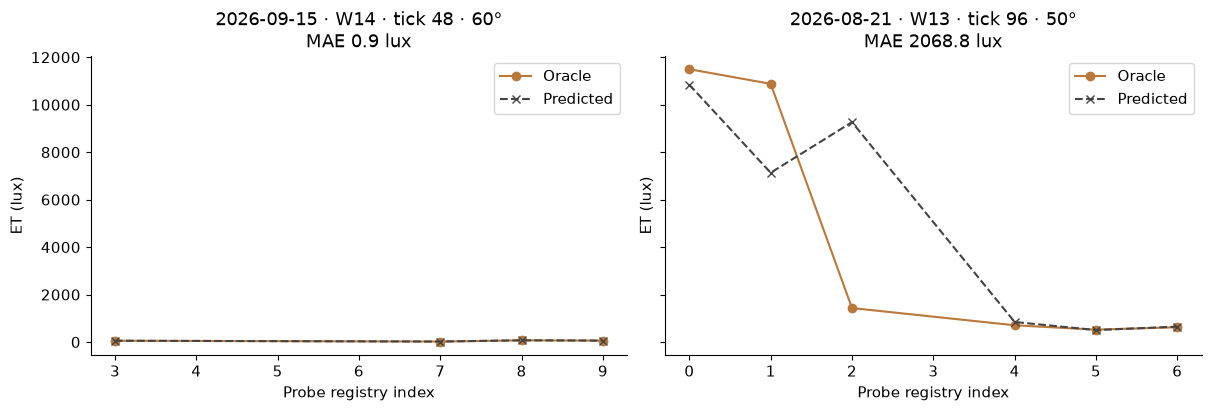

In [8]:
for target in TARGETS:
    diagnostic = training.worst_and_best_sets(predictions[target])
    display(diagnostic.round(2))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, (key, rows) in zip(
        axes, diagnostic.groupby(["set_mae_lux", "day_id", "zone", "tick", "theta_deg"], sort=True)
    ):
        ax.plot(rows.probe_index, rows.actual_lux, "o-", color=COLORS[target], label="Oracle")
        ax.plot(rows.probe_index, rows.predicted_lux, "x--", color="#444444", label="Predicted")
        ax.set(
            title=f"{key[1]} · {key[2]} · tick {key[3]} · {key[4]:g}°\nMAE {key[0]:.1f} lux",
            xlabel="Probe registry index",
            ylabel=f"{target.upper()} (lux)",
        )
        ax.legend()
    plt.show()

## 9. Run-over-run history

Existing append-only ledger plus this run’s evaluated metrics. The current run is written in the final save cell. Lines join repeated runs of the same model; this is history, not a confidence interval.

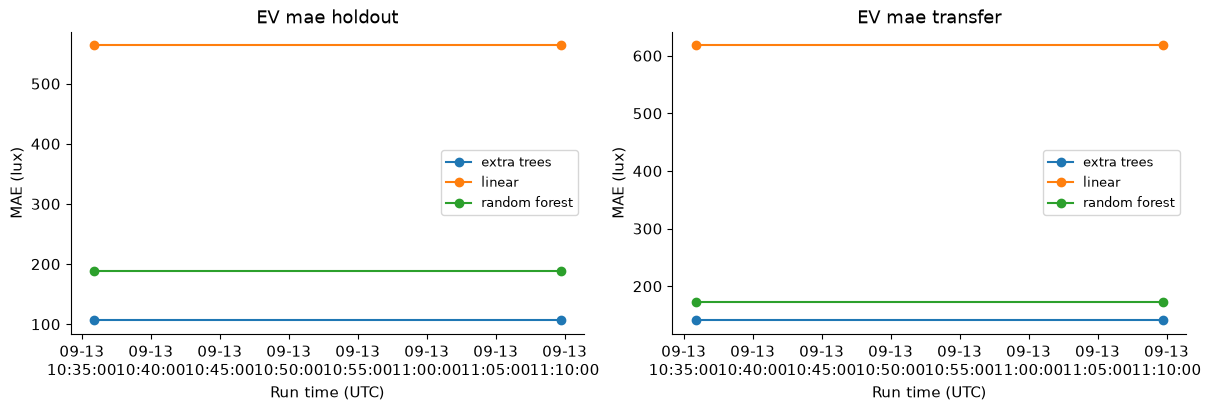

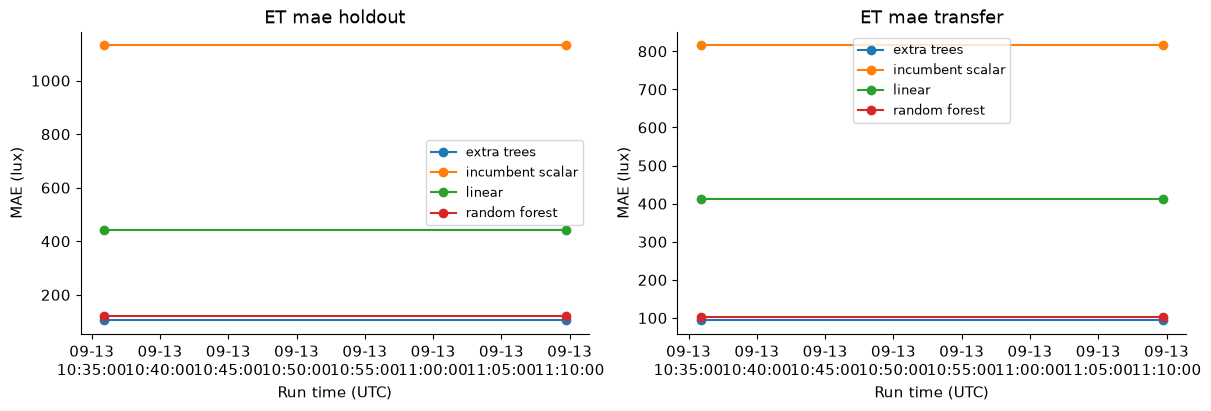

In [9]:
runs = training.history(LEDGER, pending=all_metrics)
for target in TARGETS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, measure in zip(axes, ("mae_holdout", "mae_transfer")):
        for label, rows in runs.loc[runs.target == target].groupby("model"):
            ax.plot(rows.run_at, rows[measure], marker="o", label=label)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M:%S", tz="UTC"))
        ax.set(
            title=f"{target.upper()} {measure.replace('_', ' ')}",
            xlabel="Run time (UTC)",
            ylabel="MAE (lux)",
        )
        ax.legend(fontsize=9)
    plt.show()

## 9b. Transfer verdict

The next output states the measured scope for each target, using the tolerance declared before fitting.

In [10]:
for metric in selected.values():
    display(Markdown(training.transfer_verdict(metric)[1]))

EV (extra trees): east/north transfer held: MAE 141.35 lux vs holdout 106.98 lux. Predeclared tolerance: 1.5 × holdout + 50 lux. Scope: north, east, south, west.

ET (extra trees): east/north transfer held: MAE 94.60 lux vs holdout 105.89 lux. Predeclared tolerance: 1.5 × holdout + 50 lux. Scope: north, east, south, west.

## 10. Save models, ledger and report

Artifacts are local and gitignored. This executed notebook and the append-only JSONL ledger are the tracking record. All metrics include the dataset hash, code hash, git SHA and seed.

In [11]:
summary = training.save_experiment(
    models,
    all_metrics,
    splits,
    dataset_sha256=dataset_sha256,
    ledger_path=LEDGER,
    model_dir=MODEL_DIR,
    report_path=REPORT,
)
display(Markdown(summary))

# Daylight surrogate training results

Modelled oracle labels, not measured occupant comfort. MAE (lux) is the selection criterion. MSE is lux²; R² is dimensionless. Selection uses structural holdout MAE, so it is a validation set; only orientation transfer is untouched by selection.

Shuffled rows share days/zones with fitting. Structural rows have BOTH an unseen day and unseen zone; the two cross-strata are excluded. Five-fold search groups by whole training days. Ev excludes desks, whose eye-plane target is undefined.

| Target / model | MAE shuffled | MAE holdout | MAE transfer | R² shuffled / holdout / transfer | MSE shuffled / holdout / transfer |
|---|---:|---:|---:|---|---|
| EV / extra trees | 18.13 | 106.98 | 141.35 | 0.995 / 0.971 / 0.971 | 8186 / 57069 / 53532 |
| EV / random forest | 25.59 | 187.94 | 172.15 | 0.992 / 0.926 / 0.942 | 14292 / 142802 / 106566 |
| EV / linear | 560.37 | 563.62 | 617.90 | 0.539 / 0.616 / 0.623 | 793593 / 745125 / 699323 |
| ET / extra trees | 28.57 | 105.89 | 94.60 | 0.978 / 0.962 / 0.954 | 43859 / 58401 / 30518 |
| ET / random forest | 33.63 | 121.35 | 103.55 | 0.974 / 0.954 / 0.927 | 51887 / 70883 / 47726 |
| ET / linear | 517.23 | 442.78 | 411.58 | 0.605 / 0.652 / 0.525 | 788939 / 536341 / 311501 |
| ET / incumbent scalar | 1175.49 | 1131.56 | 815.50 | -0.651 / -0.789 / -0.959 | 3296706 / 2758542 / 1285741 |

EV extra trees: structural minus shuffled MAE +88.85 lux.
ET extra trees: structural minus shuffled MAE +77.32 lux.

EV (extra trees): east/north transfer held: MAE 141.35 lux vs holdout 106.98 lux. Predeclared tolerance: 1.5 × holdout + 50 lux. Scope: north, east, south, west.

ET (extra trees): east/north transfer held: MAE 94.60 lux vs holdout 105.89 lux. Predeclared tolerance: 1.5 × holdout + 50 lux. Scope: north, east, south, west.

EV: 55,036 fit / 13,760 shuffled / 6,656 structural / 30,030 transfer; 42,848 cross-stratum rows excluded. Artifact: 191.11 MiB.

ET: 72,363 fit / 18,091 shuffled / 8,320 structural / 39,039 transfer; 55,016 cross-stratum rows excluded. Artifact: 124.56 MiB.

Seed: 42; git: `324670a061b2adacd9a857cb2aef59b28ebc91c5`; code SHA-256: `94a808763cbd09225654c67484911c39f1214d30ee71c65bc0f25d32cb994148`; dataset SHA-256: `b69fb674df4594977c5e8c9965d8fee2869537203617da32f5511e2df4a8a170`. JSONL records each target/model evaluation.

Features add incident intensity, lateral position, tilt and sky fraction to the plan's list: without these, different physical inputs can produce identical vectors. Every directional feature remains facade-relative. Fixed room/material assumptions constrain model applicability.

Method precedent: [Tabatabaei Manesh et al. (2025)](https://doi.org/10.1016/j.autcon.2025.106474). Independent local data and weights; four-bounce empty box, 4×4 patches per surface, full-wall aperture, uniform louvre-bank transmission, no furniture occlusion or glass spectral calibration. This oracle is not Radiance and does not establish measured glare or comfort.
